## 1. What this notebook computes

This notebook derives, step by step and with exact algebra (no rounding anywhere),
the field equations of gravity for the one unknown function $a_4(x_4)$ of the
author's metric. Starting from nothing but the metric, it

- writes the metric of the author in the computer-algebra package sympy and checks
  its signature and its determinant;
- computes the Christoffel symbols, the Riemann curvature tensor, the Ricci tensor,
  the Ricci scalar and the Einstein tensor;
- computes the three Lovelock tensors $E_{(1)}, E_{(2)}, E_{(3)}$ with the
  generalized Kronecker delta (the first one is the Einstein tensor, the second one
  the Gauss-Bonnet tensor), and checks the second one against the classical
  Gauss-Bonnet formula;
- writes the Einstein-Lovelock field equations with a general source and reduces
  them to a constraint, an evolution equation, a hidden-direction equation and the
  conditions every source must satisfy;
- checks the Bianchi identity and the conservation law of the source;
- specialises to Einstein gravity: no vacuum solution exists for $H > 0$, and every
  source violates the null energy condition along $x_8$;
- specialises to the linear member $a_4 = A H x_4 + a_0$ (exponentially deflating
  extra times for $A > 0$) and shows that the equations do not see the sign of $A$;
- compares every result with the Revision records and draws five teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 12a (The field equations for a4 derived with sympy) is the file
`Revision/textbook/notebooks/12a_a4_field_equations.ipynb` of the repository
Dirac_claude. It derives with sympy, from the metric of the author, the Christoffel
symbols, the Riemann, Ricci and Einstein tensors and the three Lovelock tensors (with the
generalized Kronecker delta), writes the Einstein-Lovelock field equations for a4,
reduces them to the constraint, the evolution equation, the hidden equation and the
conditions on the source, checks the Bianchi identity, the conservation law of the
source, the Einstein case (no vacuum, the null energy condition along x8) and the linear
member a4 = A H x4, compares every result with the Revision records, and draws five
teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 12a_a4_field_equations.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 12a_a4_field_equations.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
12a_a4_field_equations.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/12a.captions.json`
- `Revision/textbook/figures/12a_1_riemann_matrix.png`
- `Revision/textbook/figures/12a_2_einstein_components.png`
- `Revision/textbook/figures/12a_3_lovelock_heat_maps.png`
- `Revision/textbook/figures/12a_4_evolution_factor.png`
- `Revision/textbook/figures/12a_5_no_vacuum_gap.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all five figure files exist
    ALL 59 CHECKS PASSED (notebook 12a)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/12a_a4_field_equations.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- The cell of section 10, which computes the three Lovelock tensors, runs for a minute or
  more: it adds about five thousand products of curvature components in pure Python,
  which takes a few seconds on a fast computer and can take a few minutes on a slow one.
  The cell is not stuck: wait until the PASS lines appear below it.
- "FileNotFoundError" naming a file below the folder Revision: the notebook reads the
  Revision records of the repository. Run it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository made with git clone,
  not on a copy of the notebook file alone.
- "Jupyter command `jupyter-nbconvert` not found" or "Jupyter command `jupyter-lab` not
  found" after typing `python -m jupyter`: the program jupyter starts its parts nbconvert
  and lab as separate programs, which it looks for in the folders of the search path
  PATH, and the folder that holds them is not on it. Start the two parts as Python
  modules instead, with the environment active (Step 4) and in the folder
  Revision/textbook/notebooks (Step 5): the first command below opens the notebook in
  JupyterLab, the second runs it headless

      python -m jupyterlab 12a_a4_field_equations.ipynb
      python -m nbconvert --to notebook --execute --inplace 12a_a4_field_equations.ipynb

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 12a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 12a (The field equations for a4 derived with sympy) is the file
# Revision/textbook/notebooks/12a_a4_field_equations.ipynb of the repository
# Dirac_claude. It derives with sympy, from the metric of the author, the Christoffel
# symbols, the Riemann, Ricci and Einstein tensors and the three Lovelock tensors (with
# the generalized Kronecker delta), writes the Einstein-Lovelock field equations for a4,
# reduces them to the constraint, the evolution equation, the hidden equation and the
# conditions on the source, checks the Bianchi identity, the conservation law of the
# source, the Einstein case (no vacuum, the null energy condition along x8) and the
# linear member a4 = A H x4, compares every result with the Revision records, and draws
# five teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
# shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 12a_a4_field_equations.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 12a_a4_field_equations.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 12a_a4_field_equations.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/12a.captions.json
# - Revision/textbook/figures/12a_1_riemann_matrix.png
# - Revision/textbook/figures/12a_2_einstein_components.png
# - Revision/textbook/figures/12a_3_lovelock_heat_maps.png
# - Revision/textbook/figures/12a_4_evolution_factor.png
# - Revision/textbook/figures/12a_5_no_vacuum_gap.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all five figure files exist
#     ALL 59 CHECKS PASSED (notebook 12a)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/12a_a4_field_equations.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - The cell of section 10, which computes the three Lovelock tensors, runs for a minute
#   or more: it adds about five thousand products of curvature components in pure Python,
#   which takes a few seconds on a fast computer and can take a few minutes on a slow
#   one. The cell is not stuck: wait until the PASS lines appear below it.
# - "FileNotFoundError" naming a file below the folder Revision: the notebook reads the
#   Revision records of the repository. Run it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository made with git clone,
#   not on a copy of the notebook file alone.
# - "Jupyter command jupyter-nbconvert not found" or "Jupyter command jupyter-lab not
#   found" after typing python -m jupyter: the program jupyter starts its parts nbconvert
#   and lab as separate programs, which it looks for in the folders of the search path
#   PATH, and the folder that holds them is not on it. Start the two parts as Python
#   modules instead, with the environment active (Step 4) and in the folder
#   Revision/textbook/notebooks (Step 5): the first command below opens the notebook in
#   JupyterLab, the second runs it headless
#     python -m jupyterlab 12a_a4_field_equations.ipynb
#     python -m nbconvert --to notebook --execute --inplace 12a_a4_field_equations.ipynb
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "12a"  # this notebook: chapter 12, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 12a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$ (the author's names): $x_1, x_2, x_3$ are
  ordinary 3-space; $x_4$ is the time; $x_5, x_6, x_7$ are the three **extra
  times** (time-like directions); $x_8$ is the **hidden** space direction. In the
  code the positions 0 to 7 of a list stand for $x_1$ to $x_8$.
- **Metric** $g_{\mu\nu}$: the table of numbers that turns small coordinate steps
  into squared lengths. Here it is **diagonal**: only $g_{11}, \dots, g_{88}$ are
  not zero.
- **Scale factor**: the factor by which a length along a direction grows. 3-space
  has $e^{a_4}\sin^{1/6} z$, the extra times have $e^{-a_4}\sin^{1/6} z$.
- **Deflating**: shrinking. When $a_4$ grows, $e^{-a_4}$ shrinks: the extra times
  deflate exponentially while 3-space inflates.
- **Christoffel symbol** $\Gamma^a{}_{bc}$: the combination of first derivatives
  of the metric that tells how the coordinate directions turn from point to point.
- **Riemann tensor** $R^{ab}{}_{cd}$: the curvature; built from the Christoffel
  symbols and their derivatives. **Ricci tensor** $R^h{}_j = R^{ah}{}_{aj}$ (sum
  over $a$), **Ricci scalar** $R = R^h{}_h$, **Einstein tensor**
  $G^h{}_j = R^h{}_j - \tfrac12 \delta^h_j R$.
- **Generalized Kronecker delta** (GKD) $\delta^{h_1 \dots h_n}_{j_1 \dots j_n}$:
  $+1$ when the lower list is an even rearrangement of the upper list, $-1$ when it
  is an odd rearrangement, $0$ otherwise (also when an index repeats).
- **Lovelock tensor** $E_{(k)}$: a tensor built from $k$ factors of the Riemann
  tensor with the GKD; $E_{(1)}$ is the Einstein tensor, $E_{(2)}$ the
  Gauss-Bonnet tensor. In 8 dimensions only $k = 1, 2, 3$ exist.
- **Source**, **energy-momentum tensor** $T^\mu{}_\nu$: the matter that bends the
  metric. Its parts: the energy density $\rho = -T^{x_4}{}_{x_4}$, the pressures
  $p_3$ (3-space), $p_t$ (extra times), $p_8$ (hidden direction), and the mixed
  components $q_{48} = T^{x_4}{}_{x_8}$, $q_{84} = T^{x_8}{}_{x_4}$.
- **Couplings**: $\alpha_1, \alpha_2, \alpha_3$ (the weights of the three Lovelock
  tensors), $\Lambda$ (the cosmological constant), $\kappa$ (the strength of
  gravity). **Einstein gravity** is $\alpha_1 = 1$, $\alpha_2 = \alpha_3 = 0$.
- **Constraint**: an equation with no second derivative $a_4''$. **Evolution
  equation**: the equation that contains $a_4''$.
- **Bianchi identity**: the left-hand side of the field equations has zero
  divergence for every metric; **conservation**: the source must then have zero
  divergence too.
- **Vacuum**: no source, $T = 0$. **Null energy condition** along $x_8$:
  $\rho + p_8 \ge 0$.
- **sympy symbol**: a letter that stands for any number; `ad1` and `ad2` stand for
  $a_4' = da_4/dx_4$ and $a_4'' = d^2a_4/dx_4^2$.
- **PASS line**: a printed line that says a check passed; "reproduces" names the
  Revision record (report file and check name) that found the same result.

## 4. The physical and mathematical situation

The author's metric (the primordial gravitational field) is diagonal:

$$g = \mathrm{diag}\big(e^{2a_4}s,\ e^{2a_4}s,\ e^{2a_4}s,\ -1,\
-e^{-2a_4}s,\ -e^{-2a_4}s,\ -e^{-2a_4}s,\ \cot^2 z\big),\qquad
s = \sin^{1/3} z,\quad z = 6 H x_8 \in (0, \pi/2),$$

with $a_4 = a_4(x_4)$ and a constant $H > 0$. Its signs are
$(+,+,+,-,-,-,-,+)$: four space-like directions ($x_1, x_2, x_3, x_8$) and four
time-like ones ($x_4, \dots, x_7$), the signature (4,4).

The field equations of Einstein-Lovelock gravity are

$$\sum_{k=1}^{3} \alpha_k E_{(k)}{}^\mu{}_\nu + \Lambda \delta^\mu_\nu
= \kappa T^\mu{}_\nu,\qquad E_{(k)}{}^h{}_j = -\frac{P_{(k)}{}^h{}_j}{2^{k+1}},$$

$$P_{(k)}{}^h{}_j = \delta^{h h_1 \dots h_{2k}}_{j j_1 \dots j_{2k}}
R^{j_1 j_2}{}_{h_1 h_2} \cdots R^{j_{2k-1} j_{2k}}{}_{h_{2k-1} h_{2k}}$$

(a sum over every repeated index), with the source

$$T^\mu{}_\nu = \mathrm{diag}(p_3, p_3, p_3, -\rho, p_t, p_t, p_t, p_8)
+ q_{48}\ (\mu = x_4, \nu = x_8) + q_{84}\ (\mu = x_8, \nu = x_4).$$

Every statement this notebook checks is an exact algebraic identity (status
PROVED): sympy computes with symbols, not with rounded numbers. The plots
evaluate the exact formulas at chosen numbers, in units in which $H = 1$.

## 5. The Revision records this notebook reproduces

The Revision record contains two independent derivations of these equations (one
in the Wolfram Language, one in sympy) and an independent check by the lead. Each
writes a report file: a list of checks with a name and a verdict. The next cell
defines a helper that looks up a check by its name, and the helper `reproduces`:
a check that passes only when this notebook's own result holds AND the record
lists the named check with the verdict PASS. `reproduces` collects its two printed
lines (PASS and reproduces) in a text buffer and prints them with one call, so
that they always stay together in the output. Finally the cell prints, for each of
the four reports, how many of its checks passed, and checks that every one did:
a record with a failed check stops the notebook here. The numbers of checks are
printed, not fixed in advance, because a record may gain checks when it is
extended.

In [2]:
import contextlib  # redirect_stdout: send printed lines into a buffer
import io  # StringIO: a text buffer in memory

PY = "Revision/field_equations_a4/reports/python-a4-report.json"  # sympy record
WL = "Revision/field_equations_a4/reports/wolfram-a4-report.json"  # Wolfram record
LEAD = "Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json"  # lead check
EMT = "Revision/lead_checks/reports/emt-divergence-and-spin-connection.json"
EQUATIONS = "Revision/field_equations_a4/a4-equations.json"  # the equations
LOVELOCK = "Revision/gkd_lovelock/results/lovelock-tensors.json"  # Rust GKD output


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_verdict(report_file, name):
    """The verdict ("PASS" or "FAIL") of the check name in a report, None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry["verdict"]
    return None


def reproduces(condition, name, report_file, record_name):
    """A check that also requires the record check record_name to be PASS.  Its
    printed lines (PASS and reproduces) are collected in a text buffer and printed
    by one print call, so that they always stay together in the cell's output."""
    found = record_verdict(report_file, record_name) == "PASS"
    lines = io.StringIO()  # a text buffer
    with contextlib.redirect_stdout(lines):  # print() now writes into the buffer
        check(condition and found, name, record=f"{report_file}, check {record_name}")
    print(lines.getvalue(), end="")  # all lines at once


for report_file in (PY, WL, LEAD, EMT):
    verdicts = [entry["verdict"] for entry in read_json(report_file)["checks"]]
    passed = verdicts.count("PASS")  # how many checks of the record passed
    say(f"{report_file}: {passed} of {len(verdicts)} checks PASS")
    check(len(verdicts) > 0 and passed == len(verdicts),
          f"every check of the record {Path(report_file).name} passed")

Revision/field_equations_a4/reports/python-a4-report.json: 61 of 61 checks PASS
PASS every check of the record python-a4-report.json passed
Revision/field_equations_a4/reports/wolfram-a4-report.json: 47 of 47 checks PASS
PASS every check of the record wolfram-a4-report.json passed
Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json: 15 of 15 checks PASS
PASS every check of the record einstein-gauss-bonnet-a4.json passed
Revision/lead_checks/reports/emt-divergence-and-spin-connection.json: 10 of 10 checks
    PASS
PASS every check of the record emt-divergence-and-spin-connection.json passed


## 6. The metric in sympy

The next cell makes the symbols: $H$ (positive), $z = 6Hx_8$ (positive; we work on
the patch $0 < z < \pi/2$), the time $x_4$ and the unknown function $a_4(x_4)$. Then
it writes the eight diagonal entries of the metric as a Python list `g` (position 0
is $g_{11}$, position 7 is $g_{88}$) and prints them. sympy writes a power as `**`
and the function $a_4(x_4)$ as `a4(x4)`.

In [3]:
import itertools  # loops over all combinations of indices

import numpy as np  # arrays of numbers, used for the plots
import sympy as sp  # exact algebra with symbols

H = sp.symbols("H", positive=True)  # the constant H of the metric, H > 0
z = sp.symbols("z", positive=True)  # the hidden angle z = 6 H x8, 0 < z < pi/2
x4 = sp.symbols("x4", real=True)  # the time x4
a4 = sp.Function("a4")(x4)  # the unknown function a4(x4)
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]  # positions 0..7
N = 8  # the number of dimensions
warp = sp.sin(z) ** sp.Rational(1, 3)  # the warp factor sin(z)^(1/3)
g = ([sp.exp(2 * a4) * warp] * 3  # g11 = g22 = g33: 3-space, factor e^(2 a4)
     + [sp.Integer(-1)]  # g44 = -1: the time x4
     + [-sp.exp(-2 * a4) * warp] * 3  # g55 = g66 = g77: extra times, e^(-2 a4)
     + [sp.cot(z) ** 2])  # g88 = cot(z)^2: the hidden direction
for name, entry in zip(NAMES, g):
    say(f"g[{name},{name}] = {entry}")

g[x1,x1] = exp(2*a4(x4))*sin(z)**(1/3)
g[x2,x2] = exp(2*a4(x4))*sin(z)**(1/3)
g[x3,x3] = exp(2*a4(x4))*sin(z)**(1/3)
g[x4,x4] = -1
g[x5,x5] = -exp(-2*a4(x4))*sin(z)**(1/3)
g[x6,x6] = -exp(-2*a4(x4))*sin(z)**(1/3)
g[x7,x7] = -exp(-2*a4(x4))*sin(z)**(1/3)
g[x8,x8] = cot(z)**2


The next cell checks two facts. (1) The signs of the diagonal entries, at any
point (here $a_4 = 0$, $z = \pi/4$), are $(+,+,+,-,-,-,-,+)$. (2) The determinant
of a diagonal matrix is the product of its diagonal entries:
$\det g = (e^{2a_4}s)^3 \cdot (-1) \cdot (-e^{-2a_4}s)^3 \cot^2 z
= s^6 \cot^2 z = \sin^2 z \cot^2 z = \cos^2 z$, because $e^{6a_4} e^{-6a_4} = 1$ and
$(-1)(-1)^3 = 1$. So $\sqrt{|\det g|} = \cos z$ (positive on the patch) does not
depend on $a_4$: the volume factor $e^{3a_4}$ of the inflating 3-space and
$e^{-3a_4}$ of the deflating extra times cancel.

In [4]:
point = {a4: 0, z: sp.pi / 4}  # any point of the patch gives the same signs
signs = [int(sp.sign(entry.subs(point))) for entry in g]
say(f"signs of the diagonal entries: {signs}")
check(signs == [1, 1, 1, -1, -1, -1, -1, 1],
      "the signature is (4,4): eta = diag(+,+,+,-,-,-,-,+) in the order x1..x8")
det_g = sp.Mul(*g)  # the product of the eight diagonal entries
say(f"det g = {sp.simplify(det_g)}")
reproduces(sp.simplify(det_g - sp.cos(z) ** 2) == 0,
           "det g = cos(z)^2, so sqrt|det g| = cos z, independent of a4",
           WL, "sqrt_abs_det_g_is_cos_z")

signs of the diagonal entries: [1, 1, 1, -1, -1, -1, -1, 1]
PASS the signature is (4,4): eta = diag(+,+,+,-,-,-,-,+) in the order x1..x8
det g = cos(z)**2
PASS det g = cos(z)^2, so sqrt|det g| = cos z, independent of a4
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    sqrt_abs_det_g_is_cos_z


## 7. Derivatives and the Christoffel symbols

The metric depends on $x_4$ and on $x_8$ only, and on $x_8$ only through
$z = 6Hx_8$. By the chain rule $\partial/\partial x_8 = (dz/dx_8)\,\partial/\partial z
= 6H\,\partial/\partial z$. The function `d(expr, mu)` below takes the partial
derivative with respect to the coordinate at position `mu`.

For a diagonal metric the Christoffel symbols
$\Gamma^a{}_{bc} = \tfrac12 g^{ad}(\partial_b g_{dc} + \partial_c g_{db}
- \partial_d g_{bc})$ reduce (only $d = a$ survives, and $g^{aa} = 1/g_{aa}$) to

$$\Gamma^a{}_{bc} = \frac{1}{2g_{aa}}\big(\delta_{ac}\,\partial_b g_{aa}
+ \delta_{ab}\,\partial_c g_{aa} - \delta_{bc}\,\partial_a g_{bb}\big)$$

(no sum over $a$ or $b$). The cell computes all $8^3 = 512$ of them, counts those
that are not zero (37: the 25 distinct ones printed by the cell after it, 12 of
which appear twice because $\Gamma^a{}_{bc} = \Gamma^a{}_{cb}$ with $b \ne c$) and
checks that symmetry.

In [5]:
def d(expr, mu):
    """The partial derivative of expr with respect to the coordinate at position
    mu (0..7 for x1..x8); d/dx8 = 6 H d/dz by the chain rule."""
    if mu == 3:
        return sp.diff(expr, x4)
    if mu == 7:
        return 6 * H * sp.diff(expr, z)
    return sp.Integer(0)  # nothing depends on x1, x2, x3, x5, x6, x7


Gamma = [[[sp.Integer(0)] * N for _ in range(N)] for _ in range(N)]  # 512 zeros
for a, b, c in itertools.product(range(N), repeat=3):  # every index triple
    value = 0
    if a == c:
        value += d(g[a], b)
    if a == b:
        value += d(g[a], c)
    if b == c:
        value -= d(g[b], a)
    Gamma[a][b][c] = value / (2 * g[a])  # Gamma^a_bc of a diagonal metric
nonzero = [(a, b, c) for a, b, c in itertools.product(range(N), repeat=3)
           if Gamma[a][b][c] != 0]
say(f"{len(nonzero)} of the 512 Christoffel symbols are not zero")
check(len(nonzero) == 37,
      "37 nonzero Christoffel symbols (25 distinct, 12 of them twice)")
check(all(Gamma[a][b][c] == Gamma[a][c][b] for a, b, c in nonzero),
      "Gamma^a_bc = Gamma^a_cb (symmetric in the two lower indices)")

37 of the 512 Christoffel symbols are not zero
PASS 37 nonzero Christoffel symbols (25 distinct, 12 of them twice)
PASS Gamma^a_bc = Gamma^a_cb (symmetric in the two lower indices)


The next cell prints the Christoffel symbols that are not zero, each pair
$\Gamma^a{}_{bc} = \Gamma^a{}_{cb}$ once. The helper `readable` writes the
derivatives $a_4'$ and $a_4''$ as the symbols `ad1` and `ad2` and simplifies.
For example $\Gamma^{x_1}{}_{x_1 x_4} = \tfrac12 g^{11}\partial_4 g_{11}
= \tfrac12 \cdot 2a_4' = a_4'$ and $\Gamma^{x_5}{}_{x_4 x_5} = -a_4'$: the sign
difference between the inflating and the deflating directions.

In [6]:
# The first, second and third derivatives of a4 as plain symbols:
ad1, ad2, ad3 = sp.symbols("ad1 ad2 ad3", real=True)


def derivatives_as_symbols(expr):
    """Replace the derivatives of a4 by the symbols ad1, ad2, ad3."""
    expr = expr.subs(sp.Derivative(a4, (x4, 3)), ad3)  # highest derivative first
    expr = expr.subs(sp.Derivative(a4, (x4, 2)), ad2)
    return expr.subs(sp.Derivative(a4, x4), ad1)


def readable(expr):
    """expr with ad1, ad2 for the derivatives of a4, simplified for printing."""
    return sp.simplify(derivatives_as_symbols(expr))


for a, b, c in nonzero:
    if b <= c:  # print each symmetric pair once
        say(f"Gamma^{NAMES[a]}_{NAMES[b]}{NAMES[c]} = {readable(Gamma[a][b][c])}")

Gamma^x1_x1x4 = ad1
Gamma^x1_x1x8 = H/tan(z)
Gamma^x2_x2x4 = ad1
Gamma^x2_x2x8 = H/tan(z)
Gamma^x3_x3x4 = ad1
Gamma^x3_x3x8 = H/tan(z)
Gamma^x4_x1x1 = ad1*exp(2*a4(x4))*sin(z)**(1/3)
Gamma^x4_x2x2 = ad1*exp(2*a4(x4))*sin(z)**(1/3)
Gamma^x4_x3x3 = ad1*exp(2*a4(x4))*sin(z)**(1/3)
Gamma^x4_x5x5 = ad1*exp(-2*a4(x4))*sin(z)**(1/3)
Gamma^x4_x6x6 = ad1*exp(-2*a4(x4))*sin(z)**(1/3)
Gamma^x4_x7x7 = ad1*exp(-2*a4(x4))*sin(z)**(1/3)
Gamma^x5_x4x5 = -ad1
Gamma^x5_x5x8 = H/tan(z)
Gamma^x6_x4x6 = -ad1
Gamma^x6_x6x8 = H/tan(z)
Gamma^x7_x4x7 = -ad1
Gamma^x7_x7x8 = H/tan(z)
Gamma^x8_x1x1 = -H*exp(2*a4(x4))*sin(z)**(4/3)/cos(z)
Gamma^x8_x2x2 = -H*exp(2*a4(x4))*sin(z)**(4/3)/cos(z)
Gamma^x8_x3x3 = -H*exp(2*a4(x4))*sin(z)**(4/3)/cos(z)
Gamma^x8_x5x5 = H*exp(-2*a4(x4))*sin(z)**(4/3)/cos(z)
Gamma^x8_x6x6 = H*exp(-2*a4(x4))*sin(z)**(4/3)/cos(z)
Gamma^x8_x7x7 = H*exp(-2*a4(x4))*sin(z)**(4/3)/cos(z)
Gamma^x8_x8x8 = -12*H/sin(2*z)


## 8. The Riemann tensor

The Riemann tensor in the sign convention of Misner, Thorne and Wheeler (MTW) is

$$R^a{}_{bmn} = \partial_m \Gamma^a{}_{bn} - \partial_n \Gamma^a{}_{bm}
+ \Gamma^a{}_{me}\Gamma^e{}_{bn} - \Gamma^a{}_{ne}\Gamma^e{}_{bm}$$

(sum over $e$), and with the second index raised,
$R^{ab}{}_{mn} = g^{bb} R^a{}_{bmn}$. It is antisymmetric in $(a, b)$ and in
$(m, n)$, so only $a \ne b$, $m \ne n$ can be nonzero.

To bring every component to one canonical form, the helper `clean` writes every
function of $z$ through $c = \cot z > 0$: $\sin z = 1/\sqrt{1 + c^2}$,
$\cos z = c/\sqrt{1 + c^2}$, $\tan z = 1/c$ (from $\cot z = \cos z/\sin z$ and
$\sin^2 z + \cos^2 z = 1$), first expanding $\sin 2z = 2\sin z\cos z$. In the code
$c$ is called `cz`.

In [7]:
cz = sp.symbols("cz", positive=True)  # cz = cot z > 0 on the patch
TRIG = {sp.sin(z): 1 / sp.sqrt(1 + cz ** 2), sp.cos(z): cz / sp.sqrt(1 + cz ** 2),
        sp.tan(z): 1 / cz, sp.cot(z): cz}  # every function of z through cot z


def clean(expr):
    """expr in canonical form: derivatives of a4 as ad1, ad2, ad3; functions of z
    through cz; powers combined; common factors cancelled; expanded."""
    expr = sp.expand_trig(derivatives_as_symbols(expr)).subs(TRIG)
    return sp.expand(sp.cancel(sp.powsimp(sp.expand(expr), force=True)))


R = {}  # R[(a, b, m, n)] = R^{ab}_{mn}; only the components that are not zero
for a, b, m, n in itertools.product(range(N), repeat=4):
    if a == b or m == n:
        continue  # antisymmetry: zero when the two indices of a pair are equal
    value = (d(Gamma[a][b][n], m) - d(Gamma[a][b][m], n)
             + sum(Gamma[a][m][e] * Gamma[e][b][n] - Gamma[a][n][e] * Gamma[e][b][m]
                   for e in range(N)))  # R^a_bmn in the MTW convention
    if value != 0:
        value = clean(value / g[b])  # raise the index b: multiply by g^bb
        if value != 0:
            R[(a, b, m, n)] = value
ordered = {key: value for key, value in R.items()
           if key[0] < key[1] and key[2] < key[3]}  # a < b and m < n
report("nonzero components R^ab_mn of the 4096", len(R))
report("nonzero components with a < b and m < n", len(ordered))

RESULT nonzero components R^ab_mn of the 4096 = 156
RESULT nonzero components with a < b and m < n = 39


The next cell checks four facts that the Revision record found. (1) There are 156
nonzero components, 39 of them with $a < b$, $m < n$. (2) Not one contains the warp
factor or $e^{a_4}$: the curvature depends only on $H$, $a_4'$, $a_4''$ and
$\cot z$. (3) Every component is a polynomial in $H, a_4', a_4'', \cot z$ divided
at most by $\cot z$ (a *Laurent polynomial* in $\cot z$). (4) The pair
antisymmetry $R^{ab}{}_{mn} = -R^{ba}{}_{mn} = -R^{ab}{}_{nm}$.

In [8]:
reproduces(len(R) == 156, "156 nonzero components R^ab_mn of the 4096",
           PY, "mixed_riemann_free_of_warp_and_a4")
reproduces(len(ordered) == 39, "39 nonzero components with a < b and m < n",
           WL, "mixed_riemann_free_of_warp_and_a4")
free = all(not v.has(a4) and not v.has(z) and not v.has(sp.exp) for v in R.values())
reproduces(free, "R^ab_mn is free of the warp factor and of e^(a4)",
           PY, "mixed_riemann_free_of_warp_and_a4")
laurent = all(sp.expand(v * cz).is_polynomial(H, ad1, ad2, cz) for v in R.values())
reproduces(laurent, "every R^ab_mn is a Laurent polynomial in cot z",
           PY, "riemann_entries_laurent")
antisymmetric = all(R.get((b, a, m, n)) == -v and R.get((a, b, n, m)) == -v
                    for (a, b, m, n), v in R.items())
reproduces(antisymmetric, "R^ab_mn = -R^ba_mn = -R^ab_nm",
           PY, "riemann_pair_antisymmetry")

PASS 156 nonzero components R^ab_mn of the 4096
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    mixed_riemann_free_of_warp_and_a4
PASS 39 nonzero components with a < b and m < n
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    mixed_riemann_free_of_warp_and_a4
PASS R^ab_mn is free of the warp factor and of e^(a4)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    mixed_riemann_free_of_warp_and_a4
PASS every R^ab_mn is a Laurent polynomial in cot z
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    riemann_entries_laurent
PASS R^ab_mn = -R^ba_mn = -R^ab_nm
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    riemann_pair_antisymmetry


The next cell prints the 39 components with $a < b$, $m < n$, grouped by their
value; each member is written `x1x2|x1x2` for $R^{x_1x_2}{}_{x_1x_2}$. Read the
groups as follows: a pair of two 3-space directions, and a pair of two extra
times, has curvature $(a_4')^2 - H^2$; a 3-space direction with an extra time has
$-(a_4')^2 - H^2$; a pair with the hidden direction has $-H^2$; a 3-space
direction with the time has $(a_4')^2 + a_4''$ and an extra time with the time
$(a_4')^2 - a_4''$. The two remaining groups (12 components, written with `cz`
for $\cot z$) connect a pair that contains the time $x_4$ with the pair in which
$x_4$ is replaced by $x_8$; they are proportional to $H a_4'$, so they vanish when
$a_4$ is constant.

In [9]:
def pair_name(a, b):
    return NAMES[a] + NAMES[b]


groups = {}  # printed value -> the components that have it
for (a, b, m, n), value in ordered.items():
    label = f"{pair_name(a, b)}|{pair_name(m, n)}"
    groups.setdefault(str(value), []).append(label)
for value, members in groups.items():
    say(f"{value} ({len(members)}): " + " ".join(members))

-H**2 + ad1**2 (6): x1x2|x1x2 x1x3|x1x3 x2x3|x2x3 x5x6|x5x6 x5x7|x5x7 x6x7|x6x7
ad1**2 + ad2 (3): x1x4|x1x4 x2x4|x2x4 x3x4|x3x4
H*ad1*cz (6): x1x4|x1x8 x2x4|x2x8 x3x4|x3x8 x4x5|x5x8 x4x6|x6x8 x4x7|x7x8
-H**2 - ad1**2 (9): x1x5|x1x5 x1x6|x1x6 x1x7|x1x7 x2x5|x2x5 x2x6|x2x6 x2x7|x2x7 x3x5|x3x5
    x3x6|x3x6 x3x7|x3x7
-H*ad1/cz (6): x1x8|x1x4 x2x8|x2x4 x3x8|x3x4 x5x8|x4x5 x6x8|x4x6 x7x8|x4x7
-H**2 (6): x1x8|x1x8 x2x8|x2x8 x3x8|x3x8 x5x8|x5x8 x6x8|x6x8 x7x8|x7x8
ad1**2 - ad2 (3): x4x5|x4x5 x4x6|x4x6 x4x7|x4x7


The next cell draws the 39 components (and their zeros) as a heat map: a 28 by 28
table whose rows are the pairs $(a, b)$ with $a < b$ and whose columns are the
pairs $(m, n)$ with $m < n$, evaluated at the sample point $H = 1$,
$a_4' = 0.6$, $a_4'' = 0.3$, $z = \pi/3$ (so $\cot z = 1/\sqrt3$). Red is
positive, blue negative, white zero.

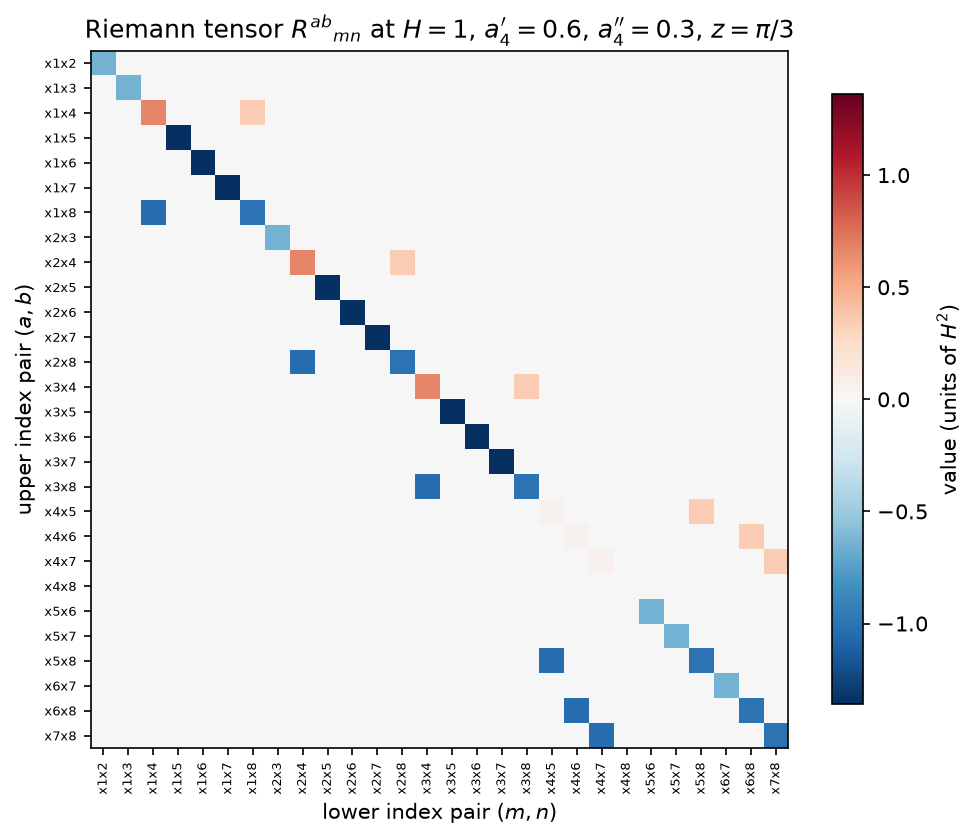

Figure 12a.1 saved as Revision/textbook/figures/12a_1_riemann_matrix.png


In [10]:
PAIRS28 = [(a, b) for a in range(N) for b in range(a + 1, N)]  # the 28 pairs
SAMPLE = {H: 1, ad1: sp.Rational(3, 5), ad2: sp.Rational(3, 10),
          cz: 1 / sp.sqrt(3)}  # H = 1, a4' = 0.6, a4'' = 0.3, z = pi/3
table = np.zeros((28, 28))
for i, (a, b) in enumerate(PAIRS28):
    for j, (m, n) in enumerate(PAIRS28):
        if (a, b, m, n) in R:
            table[i, j] = float(R[(a, b, m, n)].subs(SAMPLE))
limit = np.abs(table).max()  # the same scale for both signs
labels = [pair_name(a, b) for a, b in PAIRS28]
fig, ax = plt.subplots(figsize=(7.5, 6.6))
image = ax.imshow(table, cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(range(28))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_yticks(range(28))
ax.set_yticklabels(labels, fontsize=6)
ax.set_xlabel("lower index pair $(m, n)$")
ax.set_ylabel("upper index pair $(a, b)$")
ax.grid(False)
ax.set_title("Riemann tensor $R^{ab}{}_{mn}$ at $H=1$, $a_4'=0.6$, "
             "$a_4''=0.3$, $z=\\pi/3$")
fig.colorbar(image, ax=ax, shrink=0.8, label="value (units of $H^2$)")
save_figure(fig, "riemann_matrix",
            "The Riemann tensor $R^{ab}{}_{mn}$ of the author's metric as a 28 by "
            "28 table: rows are the index pairs $(a, b)$ with $a < b$, columns the "
            "pairs $(m, n)$ with $m < n$, colour the value in units of $H^2$ at "
            "$H = 1$, $a_4' = 0.6$, $a_4^{\\prime\\prime} = 0.3$, $z = \\pi/3$ (red "
            "positive, blue negative, white zero). Almost all of the curvature sits "
            "on the "
            "diagonal, one number per pair of directions; the only entries off the "
            "diagonal couple a pair that contains the time $x_4$ to the pair in "
            "which $x_4$ is replaced by $x_8$ (for example $x_1x_4$ and $x_1x_8$), "
            "and they are proportional to $H a_4'$.")

## 9. The Ricci tensor, the Ricci scalar and the Einstein tensor

The Ricci tensor with one index up is $R^h{}_j = \sum_a R^{ah}{}_{aj}$, the Ricci
scalar $R = \sum_h R^h{}_h$, and the Einstein tensor
$G^h{}_j = R^h{}_j - \tfrac12\delta^h_j R$. The next cell computes all 64
components of each and prints $R$ and the diagonal of $G$.

In [11]:
Ricci = [[sp.expand(sum(R.get((a, h, a, j), 0) for a in range(N)))
          for j in range(N)] for h in range(N)]  # R^h_j
ricci_scalar = sp.expand(sum(Ricci[h][h] for h in range(N)))
G = [[sp.expand(Ricci[h][j] - (ricci_scalar / 2 if h == j else 0))
      for j in range(N)] for h in range(N)]  # G^h_j
report("Ricci scalar R", ricci_scalar)
for h in range(N):
    say(f"G^{NAMES[h]}_{NAMES[h]} = {G[h][h]}")

RESULT Ricci scalar R = -42*H**2 + 6*ad1**2
G^x1_x1 = 15*H**2 - 3*ad1**2 + ad2
G^x2_x2 = 15*H**2 - 3*ad1**2 + ad2
G^x3_x3 = 15*H**2 - 3*ad1**2 + ad2
G^x4_x4 = 21*H**2 + 3*ad1**2
G^x5_x5 = 15*H**2 - 3*ad1**2 - ad2
G^x6_x6 = 15*H**2 - 3*ad1**2 - ad2
G^x7_x7 = 15*H**2 - 3*ad1**2 - ad2
G^x8_x8 = 15*H**2 - 3*ad1**2


The next cell checks the structure of $G$ and compares it with the records: every
off-diagonal component is zero (in particular $G^{x_4}{}_{x_8} = 0$); the three
3-space components are equal, and so are the three extra-time components; nothing
depends on $x_8$ (no $\cot z$ is left); and the four distinct components are

$$G^{x_4}{}_{x_4} = 3(a_4')^2 + 21H^2,\quad
G^{x_1}{}_{x_1} = a_4'' - 3(a_4')^2 + 15H^2,$$
$$G^{x_5}{}_{x_5} = -a_4'' - 3(a_4')^2 + 15H^2,\quad
G^{x_8}{}_{x_8} = -3(a_4')^2 + 15H^2.$$

In [12]:
reproduces(all(G[h][j] == 0 for h in range(N) for j in range(N) if h != j),
           "G^h_j is diagonal (in particular G^x4_x8 = G^x8_x4 = 0)",
           LEAD, "einstein_off_diagonal_zero")
reproduces(G[0][0] == G[1][1] == G[2][2] and G[4][4] == G[5][5] == G[6][6],
           "G^x1_x1 = G^x2_x2 = G^x3_x3 and G^x5_x5 = G^x6_x6 = G^x7_x7",
           LEAD, "einstein_isotropy")
reproduces(not any(G[h][j].has(cz) for h in range(N) for j in range(N)),
           "every component of G is independent of x8",
           LEAD, "einstein_x8_independent")
expected = {3: 3 * ad1 ** 2 + 21 * H ** 2, 0: ad2 - 3 * ad1 ** 2 + 15 * H ** 2,
            4: -ad2 - 3 * ad1 ** 2 + 15 * H ** 2, 7: -3 * ad1 ** 2 + 15 * H ** 2}
reproduces(all(sp.expand(G[i][i] - v) == 0 for i, v in expected.items()),
           "the four Einstein components agree with the record",
           PY, "einstein_components")

PASS G^h_j is diagonal (in particular G^x4_x8 = G^x8_x4 = 0)
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_off_diagonal_zero
PASS G^x1_x1 = G^x2_x2 = G^x3_x3 and G^x5_x5 = G^x6_x6 = G^x7_x7
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_isotropy
PASS every component of G is independent of x8
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_x8_independent
PASS the four Einstein components agree with the record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_components


The next cell draws the four distinct components of the Einstein tensor as
functions of $a_4'/H$ from $-3$ to $3$, in units of $H^2$. The 3-space and the
extra-time components are drawn twice: with $a_4'' = 0$ (they coincide with the
hidden one) and with $a_4'' = H^2$ (dashed: they split by $\pm a_4''$). This is
the origin of the evolution equation of section 11: only the difference of the
3-space and the extra-time components contains $a_4''$.

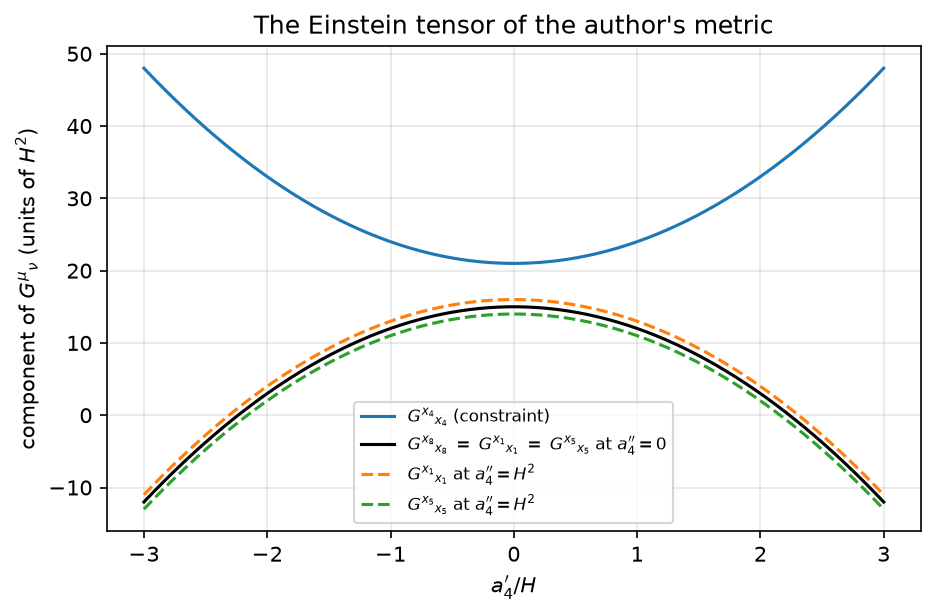

Figure 12a.2 saved as Revision/textbook/figures/12a_2_einstein_components.png


In [13]:
u = np.linspace(-3.0, 3.0, 301)  # a4'/H
fig, ax = plt.subplots()
ax.plot(u, 3 * u ** 2 + 21, label="$G^{x_4}{}_{x_4}$ (constraint)")
ax.plot(u, 15 - 3 * u ** 2, color="black",
        label="$G^{x_8}{}_{x_8}$ $=$ $G^{x_1}{}_{x_1}$ $=$ $G^{x_5}{}_{x_5}$ "
              "at $a_4''=0$")
ax.plot(u, 15 - 3 * u ** 2 + 1, "--", label="$G^{x_1}{}_{x_1}$ at $a_4''=H^2$")
ax.plot(u, 15 - 3 * u ** 2 - 1, "--", label="$G^{x_5}{}_{x_5}$ at $a_4''=H^2$")
ax.set_xlabel("$a_4'/H$")
ax.set_ylabel("component of $G^\\mu{}_\\nu$ (units of $H^2$)")
ax.set_title("The Einstein tensor of the author's metric")
ax.legend(fontsize=8)
save_figure(fig, "einstein_components",
            "The four distinct components of the Einstein tensor of the author's "
            "metric as functions of $a_4'/H$, in units of $H^2$: the time component "
            "$G^{x_4}{}_{x_4} = 3(a_4')^2 + 21H^2$ (top curve), the hidden "
            "component $G^{x_8}{}_{x_8} = 15H^2 - 3(a_4')^2$ (black), and the "
            "3-space and extra-time components, which equal the hidden one when "
            "the second derivative $a_4^{\\prime\\prime}$ is zero and split by "
            "$+a_4^{\\prime\\prime}$ and $-a_4^{\\prime\\prime}$ (dashed, drawn for "
            "$a_4^{\\prime\\prime} = H^2$). The time component is never smaller than "
            "$21H^2$, and only the difference of the 3-space and extra-time "
            "components feels $a_4^{\\prime\\prime}$.")

## 10. The three Lovelock tensors with the generalized Kronecker delta

The GKD $\delta^{h_1 \dots h_n}_{j_1 \dots j_n}$ is the determinant of the
$n \times n$ matrix of ordinary Kronecker deltas $\delta^{h_r}_{j_s}$. That
determinant is $0$ when two upper (or two lower) indices are equal (two equal
rows), and otherwise the sign of the permutation that turns the upper list into
the lower list (or $0$ when the two lists hold different indices). The next cell
implements it by counting *inversions*: pairs of positions that appear in the
wrong order. It prints three small examples and checks that 9 indices in 8
dimensions always give 0 (two of them must be equal): so there is no fourth
Lovelock tensor in 8 dimensions.

In [14]:
def gkd(upper, lower):
    """The generalized Kronecker delta: +1 (-1) if lower is an even (odd)
    rearrangement of upper without a repeated index, otherwise 0."""
    if len(set(upper)) != len(upper) or sorted(upper) != sorted(lower):
        return 0
    position = [upper.index(index) for index in lower]  # where each one sits
    inversions = sum(1 for i in range(len(position))
                     for j in range(i + 1, len(position))
                     if position[i] > position[j])
    return -1 if inversions % 2 else 1


say(f"gkd([1, 2], [1, 2]) = {gkd([1, 2], [1, 2])}, gkd([1, 2], [2, 1]) = "
    f"{gkd([1, 2], [2, 1])}, gkd([1, 1], [1, 1]) = {gkd([1, 1], [1, 1])}")
nine = list(range(8)) + [0]  # nine indices from eight values: one repeats
reproduces(gkd(nine, nine) == 0 and gkd(list(range(8)), list(range(8))) == 1,
           "a GKD of 9 indices in 8 dimensions is 0: P_(4) = 0",
           WL, "P4_vanishes_pigeonhole")

gkd([1, 2], [1, 2]) = 1, gkd([1, 2], [2, 1]) = -1, gkd([1, 1], [1, 1]) = 0
PASS a GKD of 9 indices in 8 dimensions is 0: P_(4) = 0
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    P4_vanishes_pigeonhole


In $P_{(k)}{}^h{}_j$ every curvature factor $R^{j_1 j_2}{}_{h_1 h_2}$ appears with
its index pairs in both orders. Exchanging $j_1, j_2$ changes the sign of $R$ and
of the GKD (one more inversion), so both orders give the same term; the same holds
for $h_1, h_2$. Hence the full sum is $4^k$ times the sum over the 39 components
with $j_1 < j_2$ and $h_1 < h_2$. The next cell does this sum for $k = 1, 2, 3$,
together with the Lovelock scalar $L_{(k)}$ (the same sum without $h$ and $j$).
To multiply fast, each component, a Laurent polynomial in $\cot z$, is stored as
a sympy polynomial in $H, a_4', a_4'', \cot z$ and $t = \tan z = 1/\cot z$.

In [15]:
tz = sp.symbols("tz", positive=True)  # tz = tan z = 1/cot z
GENERATORS = (H, ad1, ad2, cz, tz)
# xreplace replaces exactly the expression 1/cz by tz and leaves cz itself alone:
FACTORS = [(key, sp.Poly(value.xreplace({1 / cz: tz}), *GENERATORS))
           for key, value in ordered.items()]  # the 39 components as polynomials


def lovelock(k):
    """P_(k)^h_j (8 x 8 list of expressions), L_(k) and the number of terms."""
    zero = sp.Poly(0, *GENERATORS)
    P = [[zero] * N for _ in range(N)]
    L = zero
    terms = 0
    for factors in itertools.product(FACTORS, repeat=k):
        lower = [i for key, _ in factors for i in key[0:2]]  # upper indices of R
        upper = [i for key, _ in factors for i in key[2:4]]  # lower indices of R
        if len(set(lower)) < 2 * k or len(set(upper)) < 2 * k:
            continue  # a repeated index: the GKD is zero
        terms += 1
        product = sp.Poly(4 ** k, *GENERATORS)  # the factor 4^k
        for _, poly in factors:
            product = product * poly
        L = L + gkd(upper, lower) * product
        for h, j in itertools.product(range(N), repeat=2):
            sign = gkd([h] + upper, [j] + lower)
            if sign:
                P[h][j] = P[h][j] + sign * product
    back = {tz: 1 / cz}  # tan z back to 1/cot z
    P = [[sp.expand(P[h][j].as_expr().subs(back)) for j in range(N)]
         for h in range(N)]
    return P, sp.expand(L.as_expr().subs(back)), terms


P, Lscalar, E = {}, {}, {}
for k in (1, 2, 3):
    P[k], Lscalar[k], terms = lovelock(k)
    E[k] = [[sp.expand(-P[k][h][j] / 2 ** (k + 1)) for j in range(N)]
            for h in range(N)]  # E_(k) = -P_(k)/2^(k+1)
    say(f"k = {k}: {terms} lists of index pairs contribute; L_({k}) = {Lscalar[k]}")

k = 1: 39 lists of index pairs contribute; L_(1) = -84*H**2 + 12*ad1**2
k = 2: 690 lists of index pairs contribute; L_(2) = 3360*H**4 - 2112*H**2*ad1**2 -
    96*ad1**4
k = 3: 4410 lists of index pairs contribute; L_(3) = -40320*H**6 + 100224*H**4*ad1**2 +
    31104*H**2*ad1**4 + 1152*ad1**6


The next cell checks what the Revision record found about these tensors:
$E_{(1)} = G$ in all 64 components ($P_{(1)} = -4G$); each $E_{(k)}$ is diagonal,
free of $x_8$, equal in the three 3-space directions and in the three extra
times; the trace identity $\sum_h P_{(k)}{}^h{}_h = (8 - 2k) L_{(k)}$; and the
scalars $L_{(k)}$ agree with the Rust program of the GKD record.

In [16]:
reproduces(all(sp.expand(E[1][h][j] - G[h][j]) == 0
               for h in range(N) for j in range(N)),
           "E_(1) = G in all 64 components (P_(1) = -4 G)",
           PY, "P1_equals_minus_4_Einstein")
lovelock_json = read_json(LOVELOCK)
for k in (1, 2, 3):
    Ek = E[k]
    structure = (all(Ek[h][j] == 0 for h in range(N) for j in range(N) if h != j)
                 and Ek[0][0] == Ek[1][1] == Ek[2][2]
                 and Ek[4][4] == Ek[5][5] == Ek[6][6]
                 and not any(Ek[h][h].has(cz) for h in range(N)))
    reproduces(structure, f"E_({k}) diagonal, free of x8, isotropic in each group",
               PY, f"P{k}_structure")
    trace = sp.expand(sum(P[k][h][h] for h in range(N)) - (8 - 2 * k) * Lscalar[k])
    reproduces(trace == 0, f"trace identity sum_h P_({k})^h_h = (8 - {2 * k}) L_({k})",
               PY, f"P{k}_trace_identity")
    text = lovelock_json[f"L{k}"].replace("Derivative[1][a4][x4]", "ad1")
    rust = sp.sympify(text.replace("^", "**"), locals={"H": H, "ad1": ad1})
    reproduces(sp.expand(rust - Lscalar[k]) == 0,
               f"L_({k}) equals the Rust GKD program", PY, f"L{k}_equals_gkd_branch")

PASS E_(1) = G in all 64 components (P_(1) = -4 G)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P1_equals_minus_4_Einstein
PASS E_(1) diagonal, free of x8, isotropic in each group
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P1_structure
PASS trace identity sum_h P_(1)^h_h = (8 - 2) L_(1)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P1_trace_identity
PASS L_(1) equals the Rust GKD program
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    L1_equals_gkd_branch
PASS E_(2) diagonal, free of x8, isotropic in each group
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P2_structure
PASS trace identity sum_h P_(2)^h_h = (8 - 4) L_(2)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P2_trace_identity
PASS L_(2) equals the Rust GKD program
     reproduces Revision/field_eq

The Rust program `lovelock_gkd` of the GKD record stored every component of
$P_{(k)}{}^h{}_j$ as a list of monomials: a fraction and the exponents of $H$,
$a_4', a_4'', a_4''', a_4''''$, $e^{a_4}$, $\sin^{1/3} z$ and $\cot z$. The next
cell rebuilds all $3 \times 64$ components from those lists and compares them with
ours; it also compares the four distinct components of each $E_{(k)}$ with the
Wolfram record `a4-equations.json`.

In [17]:
symbols_of_monomial = (H, ad1, ad2, ad3, sp.Symbol("ad4"), sp.Symbol("Ee"),
                       sp.Symbol("Ss"), cz)  # the order of the exponents


def from_monomials(monomials):
    """A component of the Rust record as a sympy expression."""
    total = sp.Integer(0)
    for numerator, denominator, exponents in monomials:
        term = sp.Rational(numerator, denominator)
        for symbol, power in zip(symbols_of_monomial, exponents):
            term *= symbol ** power
        total += term
    return total


for k in (1, 2, 3):
    block = lovelock_json[f"P{k}_mixed_up_h_down_j"]
    same = all(sp.expand(from_monomials(block[f"{NAMES[h]},{NAMES[j]}"]["monomials"])
                         - P[k][h][j]) == 0 for h in range(N) for j in range(N))
    reproduces(same, f"all 64 components of P_({k}) equal the Rust GKD record",
               PY, f"P{k}_equals_gkd_branch_monomials")
equations_json = read_json(EQUATIONS)
LOCALS = {"ad1": ad1, "ad2": ad2, "H": H}


def parse(text, names=None):
    """A Wolfram InputForm text of the record as a sympy expression."""
    return sp.sympify(text.replace("^", "**"), locals=names or LOCALS)


POSITIONS = {"x1x1": (0, 0), "x4x4": (3, 3), "x5x5": (4, 4), "x8x8": (7, 7),
             "x4x8": (3, 7), "x8x4": (7, 3)}
same = all(sp.expand(parse(equations_json["lovelockTensors"][f"E{k}"][key]["input"])
                     - E[k][h][j]) == 0
           for k in (1, 2, 3) for key, (h, j) in POSITIONS.items())
reproduces(same, "E_(1), E_(2), E_(3) equal the Wolfram record a4-equations.json",
           PY, "json_lovelock_components")

PASS all 64 components of P_(1) equal the Rust GKD record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P1_equals_gkd_branch_monomials
PASS all 64 components of P_(2) equal the Rust GKD record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P2_equals_gkd_branch_monomials
PASS all 64 components of P_(3) equal the Rust GKD record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    P3_equals_gkd_branch_monomials
PASS E_(1), E_(2), E_(3) equal the Wolfram record a4-equations.json
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_lovelock_components


**An independent route to $E_{(2)}$.** The Gauss-Bonnet tensor has a classical
formula (Lanczos), written here with one index up:

$$H^\mu{}_\nu = 2\big(R\,R^\mu{}_\nu - 2R^\mu{}_a R^a{}_\nu
- 2R^{\mu a}{}_{\nu b} R^b{}_a + R^{\mu a}{}_{bc} R^{bc}{}_{\nu a}\big)
- \tfrac12\delta^\mu_\nu\big(R^2 - 4R^a{}_b R^b{}_a
+ R^{ab}{}_{cd} R^{cd}{}_{ab}\big).$$

It uses no GKD. The next cell computes it from our Riemann tensor for a general
$a_4$ and checks that it equals $E_{(2)}$ in all 64 components. For the linear
member ($a_4' = AH$, $a_4'' = 0$) it then reproduces the lead's numbers
$H^{x_4}{}_{x_4} = -H^4(36A^4 + 120A^2 + 420)$ and
$H^{x_1}{}_{x_1} = 12H^4(A^4 + 14A^2 - 15)$.

In [18]:
def contract(mu, nu):
    """The four products in the bracket of the Lanczos formula."""
    term_a = ricci_scalar * Ricci[mu][nu]
    term_b = sum(Ricci[mu][a] * Ricci[a][nu] for a in range(N))
    term_c = sum(R.get((mu, a, nu, b), 0) * Ricci[b][a]
                 for a in range(N) for b in range(N))
    term_d = sum(R.get((mu, a, b, c), 0) * R.get((b, c, nu, a), 0)
                 for a in range(N) for b in range(N) for c in range(N))
    return 2 * (term_a - 2 * term_b - 2 * term_c + term_d)


gauss_bonnet_scalar = (ricci_scalar ** 2
                       - 4 * sum(Ricci[a][b] * Ricci[b][a]
                                 for a in range(N) for b in range(N))
                       + sum(v * R.get((m, n, a, b), 0)
                             for (a, b, m, n), v in R.items()))
lanczos = [[sp.expand(contract(mu, nu)
                      - (gauss_bonnet_scalar / 2 if mu == nu else 0))
            for nu in range(N)] for mu in range(N)]
check(all(sp.expand(lanczos[h][j] - E[2][h][j]) == 0
          for h in range(N) for j in range(N)),
      "E_(2) (GKD) equals the classical Gauss-Bonnet tensor for every a4")
A = sp.symbols("A", real=True)  # the slope of the linear member, a4' = A H
LINEAR = {ad1: A * H, ad2: 0}
reproduces(sp.expand(lanczos[3][3].subs(LINEAR)
                     + H ** 4 * (36 * A ** 4 + 120 * A ** 2 + 420)) == 0,
           "linear member: Gauss-Bonnet H^x4_x4 = -H^4 (36 A^4 + 120 A^2 + 420)",
           LEAD, "gauss_bonnet_rho_alpha2")
reproduces(sp.expand(lanczos[0][0].subs(LINEAR)
                     - 12 * H ** 4 * (A ** 4 + 14 * A ** 2 - 15)) == 0,
           "linear member: Gauss-Bonnet H^x1_x1 = 12 H^4 (A^4 + 14 A^2 - 15)",
           LEAD, "gauss_bonnet_p_alpha2")

PASS E_(2) (GKD) equals the classical Gauss-Bonnet tensor for every a4
PASS linear member: Gauss-Bonnet H^x4_x4 = -H^4 (36 A^4 + 120 A^2 + 420)
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    gauss_bonnet_rho_alpha2
PASS linear member: Gauss-Bonnet H^x1_x1 = 12 H^4 (A^4 + 14 A^2 - 15)
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    gauss_bonnet_p_alpha2


**The Bianchi identity.** Lovelock's theorem says that each $E_{(k)}$ has zero
divergence for every metric. The next cell checks this directly: it computes
$\nabla_\mu E^\mu{}_\nu = \partial_\mu E^\mu{}_\nu + \Gamma^\mu{}_{\mu l}
E^l{}_\nu - \Gamma^l{}_{\mu\nu} E^\mu{}_l$ (sums over $\mu$ and $l$) for
$\nu = x_1, \dots, x_8$, with $a_4'$ and $a_4''$ written back as derivatives of
the function $a_4(x_4)$ so that $\partial_4$ can act on them.

In [19]:
def divergence(T):
    """nabla_mu T^mu_nu of a mixed tensor T (8 x 8 list), for nu = x1..x8."""
    return [clean(sum(d(T[m][n], m) for m in range(N))
                  + sum(Gamma[m][m][l] * T[l][n] for m in range(N) for l in range(N))
                  - sum(Gamma[l][m][n] * T[m][l] for m in range(N) for l in range(N)))
            for n in range(N)]


AS_FUNCTIONS = {ad2: sp.Derivative(a4, (x4, 2)), ad1: sp.Derivative(a4, x4)}
for k in (1, 2, 3):
    Ek_functions = [[E[k][h][j].subs(AS_FUNCTIONS) for j in range(N)]
                    for h in range(N)]
    reproduces(all(value == 0 for value in divergence(Ek_functions)),
               f"nabla_mu E_({k})^mu_nu = 0 for nu = x1..x8",
               PY, f"E{k}_divergence_free")

PASS nabla_mu E_(1)^mu_nu = 0 for nu = x1..x8
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    E1_divergence_free
PASS nabla_mu E_(2)^mu_nu = 0 for nu = x1..x8
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    E2_divergence_free
PASS nabla_mu E_(3)^mu_nu = 0 for nu = x1..x8
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    E3_divergence_free


The next cell draws the diagonal of $E_{(1)}, E_{(2)}, E_{(3)}$ at the sample point
$H = 1$, $a_4' = 0.6$, $a_4'' = 0.3$ as three 8 by 8 heat maps, with the value
written in each diagonal cell. Each panel has its own colour scale. All three
tensors have the same pattern: diagonal, one value for $x_1 = x_2 = x_3$, one for
$x_4$, one for $x_5 = x_6 = x_7$, one for $x_8$.

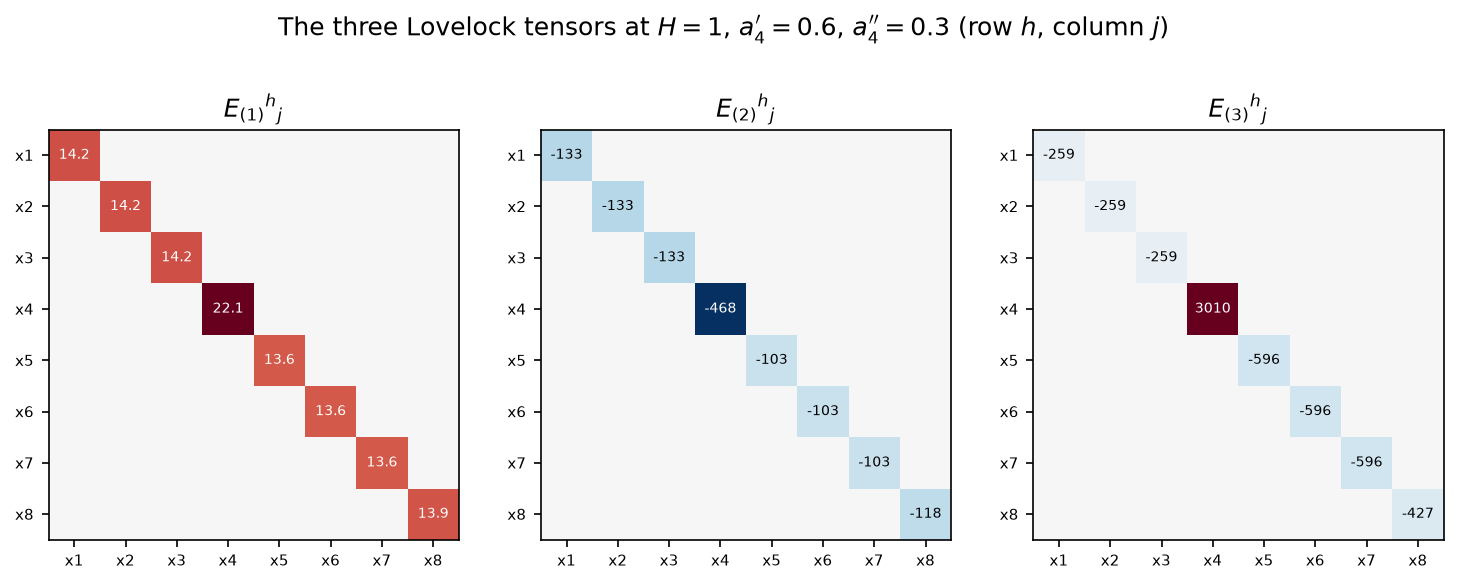

Figure 12a.3 saved as Revision/textbook/figures/12a_3_lovelock_heat_maps.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.4))
for ax, k in zip(axes, (1, 2, 3)):
    values = np.array([[float(E[k][h][j].subs(SAMPLE)) for j in range(N)]
                       for h in range(N)])
    scale = np.abs(values).max()
    ax.imshow(values, cmap="RdBu_r", vmin=-scale, vmax=scale)
    for h in range(N):  # write each diagonal value into its cell
        value = values[h, h]
        text = f"{value:.0f}" if abs(value) >= 100 else f"{value:.1f}"
        ink = "white" if abs(value) > 0.6 * scale else "black"  # readable on dark
        ax.text(h, h, text, ha="center", va="center", fontsize=6.5, color=ink)
    ax.set_xticks(range(N))
    ax.set_xticklabels(NAMES, fontsize=7)
    ax.set_yticks(range(N))
    ax.set_yticklabels(NAMES, fontsize=7)
    ax.grid(False)
    ax.set_title(f"$E_{{({k})}}{{}}^h{{}}_j$")
fig.suptitle("The three Lovelock tensors at $H=1$, $a_4'=0.6$, $a_4''=0.3$ "
             "(row $h$, column $j$)")
save_figure(fig, "lovelock_heat_maps",
            "The three Lovelock tensors $E_{(1)}$ (the Einstein tensor), $E_{(2)}$ "
            "(the Gauss-Bonnet tensor) and $E_{(3)}$ of the author's metric as 8 by "
            "8 tables, row $h$ and column $j$ running over $x_1$ to $x_8$, evaluated "
            "at $H = 1$, $a_4' = 0.6$, $a_4^{\\prime\\prime} = 0.3$; the colour is "
            "the value (each panel with its own scale, red positive, blue negative, "
            "white zero) and "
            "the number in each diagonal cell is the value (one decimal below 100, "
            "a whole number above). All off-diagonal entries are zero, and each "
            "tensor has only four different diagonal values: one for 3-space, one "
            "for the time, one for the extra times and one for the hidden "
            "direction.")

## 11. The field equations and their independent components

The next cell writes the left-hand side
$\sum_k \alpha_k E_{(k)}{}^h{}_j + \Lambda\delta^h_j$ and the source $T^h{}_j$ and
checks that every off-diagonal left-hand side is zero (so the field equations
there read $0 = \kappa T^h{}_j$: the source must have $q_{48} = q_{84} = 0$ and no
other mixed component), and that the diagonal reduces to four independent
components. It names the four: `e44` (time), `e11` (3-space), `e55` (extra times),
`e88` (hidden), each without the $\Lambda$.

In [21]:
alpha1, alpha2, alpha3 = sp.symbols("alpha1 alpha2 alpha3", real=True)
Lam, kappa = sp.symbols("Lam kappa", real=True)  # Lambda and kappa
rho, p3, pt, p8, q48, q84 = sp.symbols("rho p3 pt p8 q48 q84", real=True)
ALPHA = {1: alpha1, 2: alpha2, 3: alpha3}
LHS = [[sp.expand(sum(ALPHA[k] * E[k][h][j] for k in (1, 2, 3))
                  + (Lam if h == j else 0)) for j in range(N)] for h in range(N)]
T = [[sp.Integer(0)] * N for _ in range(N)]
for i, value in enumerate([p3, p3, p3, -rho, pt, pt, pt, p8]):
    T[i][i] = value  # the diagonal of the source
T[3][7], T[7][3] = q48, q84  # the two mixed components x4-x8 and x8-x4
off_diagonal_zero = all(LHS[h][j] == 0 for h in range(N) for j in range(N)
                        if h != j)
groups_equal = (LHS[0][0] == LHS[1][1] == LHS[2][2]
                and LHS[4][4] == LHS[5][5] == LHS[6][6])
reproduces(off_diagonal_zero and groups_equal,
           "every off-diagonal left-hand side is 0; four independent components",
           WL, "independent_components")
e11, e44, e55, e88 = (sp.expand(LHS[i][i] - Lam) for i in (0, 3, 4, 7))
say(f"constraint (x4): {e44} + Lam = -kappa*rho")
say(f"hidden (x8): {e88} + Lam = kappa*p8")

PASS every off-diagonal left-hand side is 0; four independent components
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    independent_components
constraint (x4): 2520*H**6*alpha3 + 1080*H**4*ad1**2*alpha3 - 420*H**4*alpha2 +
    648*H**2*ad1**4*alpha3 - 120*H**2*ad1**2*alpha2 + 21*H**2*alpha1 + 360*ad1**6*alpha3
    - 36*ad1**4*alpha2 + 3*ad1**2*alpha1 + Lam = -kappa*rho
hidden (x8): 360*H**6*alpha3 - 1944*H**4*ad1**2*alpha3 - 180*H**4*alpha2 -
    648*H**2*ad1**4*alpha3 + 168*H**2*ad1**2*alpha2 + 15*H**2*alpha1 - 72*ad1**6*alpha3 +
    12*ad1**4*alpha2 - 3*ad1**2*alpha1 + Lam = kappa*p8


**The evolution equation.** The 3-space equation minus the extra-time equation
removes $\Lambda$: $e_{11} - e_{55} = \kappa(p_3 - p_t)$. The next cell shows that
$e_{11} - e_{55}$ is $a_4''$ times a polynomial $F(a_4')$, that $F$ vanishes for
every $a_4'$ and $H$ only when $\alpha_1 = \alpha_2 = \alpha_3 = 0$, and that the
3-space plus the extra-time equation is exactly twice the hidden equation
(so the source must satisfy $p_3 + p_t = 2p_8$). It also checks that the time
and hidden components contain no $a_4''$.

In [22]:
F = sp.expand(sp.cancel((e11 - e55) / ad2))  # (e11 - e55)/a4''
report("F(a4')", F)
reproduces(not F.has(ad2) and sp.expand(ad2 * F - (e11 - e55)) == 0,
           "evolution: e11 - e55 = a4'' F(a4') = kappa (p3 - pt)",
           PY, "evolution_factorises")
coefficients = sp.Poly(F, ad1, H).coeffs()  # every coefficient must vanish
solutions = sp.solve(coefficients, [alpha1, alpha2, alpha3], dict=True)
reproduces(solutions == [{alpha1: 0, alpha2: 0, alpha3: 0}],
           "F vanishes identically only for alpha1 = alpha2 = alpha3 = 0",
           PY, "evolution_F_not_identically_zero")
reproduces(sp.expand(e11 + e55 - 2 * e88) == 0,
           "e11 + e55 = 2 e88 identically: the source needs p3 + pt = 2 p8",
           PY, "algebraic_identity")
reproduces(not e44.has(ad2) and not e88.has(ad2),
           "the x4 (constraint) and x8 components contain a4' but not a4''",
           PY, "constraint_and_x8_first_order")

RESULT F(a4') = 720*H**4*alpha3 + 864*H**2*ad1**2*alpha3 - 80*H**2*alpha2 +
    720*ad1**4*alpha3 - 48*ad1**2*alpha2 + 2*alpha1
PASS evolution: e11 - e55 = a4'' F(a4') = kappa (p3 - pt)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    evolution_factorises
PASS F vanishes identically only for alpha1 = alpha2 = alpha3 = 0
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    evolution_F_not_identically_zero
PASS e11 + e55 = 2 e88 identically: the source needs p3 + pt = 2 p8
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    algebraic_identity
PASS the x4 (constraint) and x8 components contain a4' but not a4''
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    constraint_and_x8_first_order


**The constraint and the evolution equation are linked (Bianchi identity).**
$e_{44}$ depends on $x_4$ only through $a_4'$, so by the chain rule
$\tfrac{d}{dx_4} e_{44} = \tfrac{\partial e_{44}}{\partial a_4'}\,a_4''$. The next
cell checks $\tfrac{d}{dx_4} e_{44} = 3a_4'(e_{11} - e_{55})$: the derivative of
the constraint is $3a_4'$ times the evolution equation. Hence, when the source
obeys $\rho' = -3a_4'(p_3 - p_t)$ (section 12), the constraint stays true along
a solution of the evolution equation. The cell also compares the four component
equations, $F$ and the algebraic condition with the Wolfram record.

In [23]:
reproduces(sp.expand(sp.diff(e44, ad1) * ad2 - 3 * ad1 * (e11 - e55)) == 0,
           "d/dx4 e44 = 3 a4' (e11 - e55) (constraint propagation)",
           PY, "bianchi_x4")
general = equations_json["generalSource"]
NAMES_RECORD = {"ad1": ad1, "ad2": ad2, "H": H, "alpha1": alpha1, "alpha2": alpha2,
                "alpha3": alpha3, "Lam": Lam, "kappa": kappa, "rho": rho, "p3": p3,
                "pt": pt, "p8": p8, "AA": A}


def parse_equation(text):
    """An equation "left == right" of the record as left - right."""
    left, right = text.split(" == ")
    return sp.expand(parse(left, NAMES_RECORD) - parse(right, NAMES_RECORD))


mine = {"constraint_x4": e44 + Lam + kappa * rho,
        "space_x1_eq_x2_eq_x3": e11 + Lam - kappa * p3,
        "extraTime_x5_eq_x6_eq_x7": e55 + Lam - kappa * pt,
        "hidden_x8": e88 + Lam - kappa * p8,
        "evolution_x1_minus_x5": ad2 * F - kappa * (p3 - pt),
        "algebraic_condition": p3 + pt - 2 * p8}
same = all(sp.expand(parse_equation(general[key]["input"]) - value) == 0
           for key, value in mine.items())
same = same and sp.expand(parse(general["evolution_F"]["input"], NAMES_RECORD)
                          - F) == 0
reproduces(same, "the six equations and F equal the record a4-equations.json",
           PY, "json_general_source_equations")

PASS d/dx4 e44 = 3 a4' (e11 - e55) (constraint propagation)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    bianchi_x4
PASS the six equations and F equal the record a4-equations.json
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_general_source_equations


The next cell draws $F(a_4')/2$ for Einstein gravity ($F = 2$: the evolution
equation is simply $2a_4'' = \kappa(p_3 - p_t)$) and for several Lovelock
couplings, in units $H = 1$. Where $F = 0$ the evolution equation cannot be solved
for $a_4''$: for Einstein-Gauss-Bonnet gravity with $\alpha_2 > 0$ this happens at
$(a_4')^2 = (1 - 40\alpha_2H^2)/(24\alpha_2)$, which follows from
$F = 2 - 80\alpha_2H^2 - 48\alpha_2(a_4')^2 = 0$.

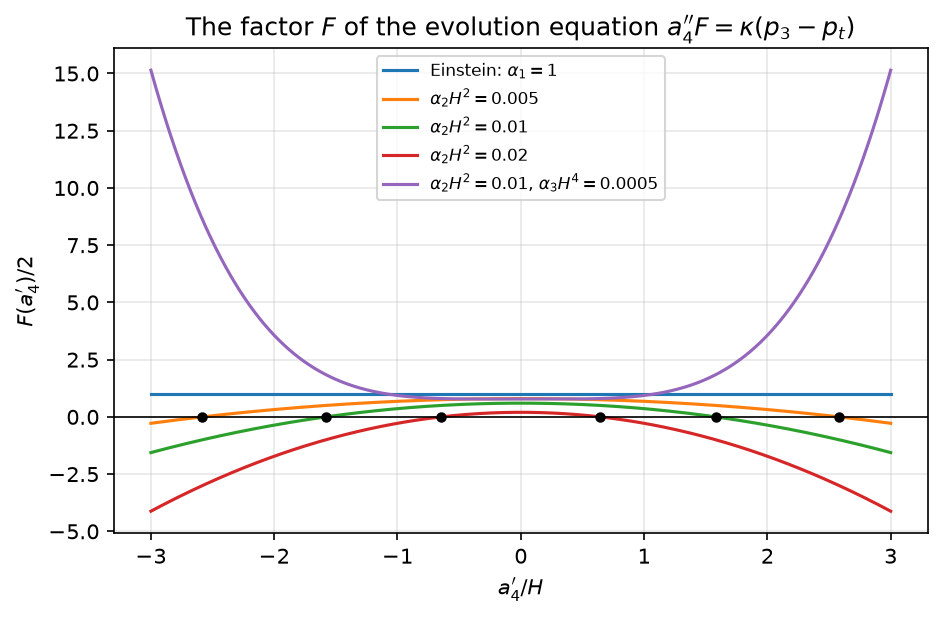

Figure 12a.4 saved as Revision/textbook/figures/12a_4_evolution_factor.png


In [24]:
F_numeric = sp.lambdify((ad1, alpha1, alpha2, alpha3), F.subs(H, 1), "numpy")
u = np.linspace(-3.0, 3.0, 601)  # a4'/H
cases = [(1, 0.0, 0.0, "Einstein: $\\alpha_1=1$"),
         (1, 0.005, 0.0, "$\\alpha_2H^2=0.005$"),
         (1, 0.01, 0.0, "$\\alpha_2H^2=0.01$"),
         (1, 0.02, 0.0, "$\\alpha_2H^2=0.02$"),
         (1, 0.01, 0.0005, "$\\alpha_2H^2=0.01$, $\\alpha_3H^4=0.0005$")]
fig, ax = plt.subplots()
for a1, a2, a3, label in cases:
    values = F_numeric(u, a1, a2, a3) * np.ones_like(u) / 2
    ax.plot(u, values, label=label)
for a2 in (0.005, 0.01, 0.02):  # the zeros of F for Gauss-Bonnet gravity
    root = np.sqrt((1 - 40 * a2) / (24 * a2))
    ax.plot([-root, root], [0, 0], "o", color="black", markersize=4)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("$a_4'/H$")
ax.set_ylabel("$F(a_4')/2$")
ax.set_title("The factor $F$ of the evolution equation $a_4''F = \\kappa(p_3-p_t)$")
ax.legend(fontsize=8)
save_figure(fig, "evolution_factor",
            "The factor $F(a_4')$ of the evolution equation "
            "$a_4^{\\prime\\prime} F(a_4') = \\kappa(p_3 - p_t)$, divided by 2, as a "
            "function of $a_4'/H$ (units $H = 1$) for Einstein gravity ($F = 2$, flat "
            "line), for "
            "Einstein-Gauss-Bonnet gravity with $\\alpha_2 H^2 = 0.005$, $0.01$, "
            "$0.02$, and with a third-order coupling $\\alpha_3 H^4 = 0.0005$ added. "
            "Black dots mark the zeros of the Gauss-Bonnet curves, at "
            "$(a_4')^2 = (1 - 40\\alpha_2H^2)/(24\\alpha_2)$: there the evolution "
            "equation cannot be solved for $a_4^{\\prime\\prime}$. The third-order "
            "term lifts the curve again at large $a_4'$.")

## 12. The conservation law of the source

The Bianchi identity makes the divergence of the left-hand side zero, so the field
equations can hold only if the source has zero divergence too. The next cell
computes $\nabla_\mu T^\mu{}_\nu$ for a general source whose seven parts
$\rho, p_3, p_t, p_8, q_{48}, q_{84}$ are arbitrary functions of $x_4$ and $x_8$,
and compares it with the record:

$$\nabla_\mu T^\mu{}_{x_4} = -\partial_4\rho - 3a_4'(p_3 - p_t)
+ \partial_8 q_{84} - 6H\tan z\, q_{84},$$
$$\nabla_\mu T^\mu{}_{x_8} = \partial_8 p_8 + 3H\cot z\,(2p_8 - p_3 - p_t)
+ \partial_4 q_{48},$$

and zero for the six other $\nu$. With an $x_8$-independent source and
$q_{48} = q_{84} = 0$ this is $\rho' = -3a_4'(p_3 - p_t)$ and
$p_3 + p_t = 2p_8$: the energy of the source changes only when the 3-space and the
extra-time pressures differ, and the hidden equation repeats the algebraic
condition.

In [25]:
source = {name: sp.Function(name)(x4, z)
          for name in ("rho", "p3", "pt", "p8", "q48", "q84")}  # f(x4, z)
Tgeneral = [[sp.Integer(0)] * N for _ in range(N)]
for i, name in enumerate(["p3", "p3", "p3", "rho", "pt", "pt", "pt", "p8"]):
    Tgeneral[i][i] = source[name]
Tgeneral[3][3] = -source["rho"]  # T^x4_x4 = -rho
Tgeneral[3][7], Tgeneral[7][3] = source["q48"], source["q84"]
divT = divergence(Tgeneral)
a4p = sp.Derivative(a4, x4)  # a4' as a derivative, for the comparison
expect_x4 = (-d(source["rho"], 3) - 3 * a4p * (source["p3"] - source["pt"])
             + d(source["q84"], 7) - 6 * H * sp.tan(z) * source["q84"])
expect_x8 = (d(source["p8"], 7) + d(source["q48"], 3)
             + 3 * H * sp.cot(z) * (2 * source["p8"] - source["p3"] - source["pt"]))
reproduces(clean(divT[3] - expect_x4) == 0, "nabla_mu T^mu_x4 as in the record",
           EMT, "divergence_x4_component")
reproduces(clean(divT[7] - expect_x8) == 0, "nabla_mu T^mu_x8 as in the record",
           EMT, "divergence_x8_component")
reproduces(all(divT[n] == 0 for n in (0, 1, 2, 4, 5, 6)),
           "nabla_mu T^mu_nu = 0 identically for the six other nu",
           PY, "conservation_components")

PASS nabla_mu T^mu_x4 as in the record
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check divergence_x4_component
PASS nabla_mu T^mu_x8 as in the record
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check divergence_x8_component
PASS nabla_mu T^mu_nu = 0 identically for the six other nu
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    conservation_components


## 13. Einstein gravity: no vacuum, and the null energy condition along $x_8$

In Einstein gravity ($\alpha_1 = 1$, $\alpha_2 = \alpha_3 = 0$) the equations read

$$3(a_4')^2 + 21H^2 + \Lambda = -\kappa\rho,\qquad 2a_4'' = \kappa(p_3 - p_t),
\qquad -3(a_4')^2 + 15H^2 + \Lambda = \kappa p_8.$$

Adding the first and the third: $-\kappa\rho + \kappa p_8 = 36H^2 + 2\Lambda$.
Subtracting the first from the third: $\kappa(\rho + p_8) = -6(a_4')^2 - 6H^2$,
which is negative for every $a_4$ and every $\Lambda$: the source always violates
the null energy condition along the null direction $x_4 + x_8$ (for $\kappa > 0$).
A vacuum ($T = 0$) would need $6(a_4')^2 + 6H^2 = 0$, impossible for real $a_4'$
and $H > 0$. The next cell checks both and lets sympy solve the vacuum equations:
the only solutions have the imaginary slope $a_4' = \pm iH$.

In [26]:
EINSTEIN = {alpha1: 1, alpha2: 0, alpha3: 0}
null_x8 = sp.expand((e88 - e44).subs(EINSTEIN))  # kappa (rho + p8)
report("Einstein: kappa (rho + p8)", null_x8)
reproduces(sp.expand(null_x8 + 6 * ad1 ** 2 + 6 * H ** 2) == 0,
           "Einstein: kappa (rho + p8) = -6 (a4'^2 + H^2) < 0",
           PY, "einstein_null_energy_x8")
vacuum = [LHS[i][i].subs(EINSTEIN) for i in (0, 3, 4, 7)]  # T = 0
real_solutions = sp.solve(vacuum, [Lam, ad1, ad2], dict=True)  # ad1, ad2 real
say(f"real solutions of the vacuum equations: {real_solutions}")
w1, w2 = sp.symbols("w1 w2")  # a4' and a4'' again, now allowed to be complex
as_complex = [value.subs({ad1: w1, ad2: w2}) for value in vacuum]
complex_solutions = sorted(sp.solve(as_complex, [Lam, w1, w2], dict=True), key=str)
say(f"solutions when a4' = w1 and a4'' = w2 may be complex: {complex_solutions}")
imaginary = all(not solution[w1].is_real for solution in complex_solutions)
reproduces(real_solutions == [] and len(complex_solutions) == 2 and imaginary,
           "Einstein: no real vacuum solution for H > 0 and any Lambda",
           LEAD, "no_vacuum_for_H_positive")
einstein_record = equations_json["einstein"]
mine_einstein = {"constraint_x4": e44.subs(EINSTEIN) + Lam + kappa * rho,
                 "hidden_x8": e88.subs(EINSTEIN) + Lam - kappa * p8,
                 "evolution": 2 * ad2 - kappa * (p3 - pt)}
same = all(sp.expand(parse_equation(einstein_record[key]["input"]) - value) == 0
           for key, value in mine_einstein.items())
reproduces(same, "the Einstein equations equal the record", PY, "json_einstein")

RESULT Einstein: kappa (rho + p8) = -6*H**2 - 6*ad1**2
PASS Einstein: kappa (rho + p8) = -6 (a4'^2 + H^2) < 0
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_null_energy_x8
real solutions of the vacuum equations: []
solutions when a4' = w1 and a4'' = w2 may be complex: [{Lam: -18*H**2, w1: -I*H, w2: 0},
    {Lam: -18*H**2, w1: I*H, w2: 0}]
PASS Einstein: no real vacuum solution for H > 0 and any Lambda
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    no_vacuum_for_H_positive
PASS the Einstein equations equal the record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_einstein


The next cell draws the reason why there is no vacuum. With $T = 0$ the
constraint asks for $\Lambda = -(3(a_4')^2 + 21H^2)$ and the hidden equation for
$\Lambda = 3(a_4')^2 - 15H^2$. As functions of $a_4'$ the two curves never meet:
the first is never above $-21H^2$, the second never below $-15H^2$. The vertical
distance between them is $6(a_4')^2 + 6H^2 = -\kappa(\rho + p_8)$.

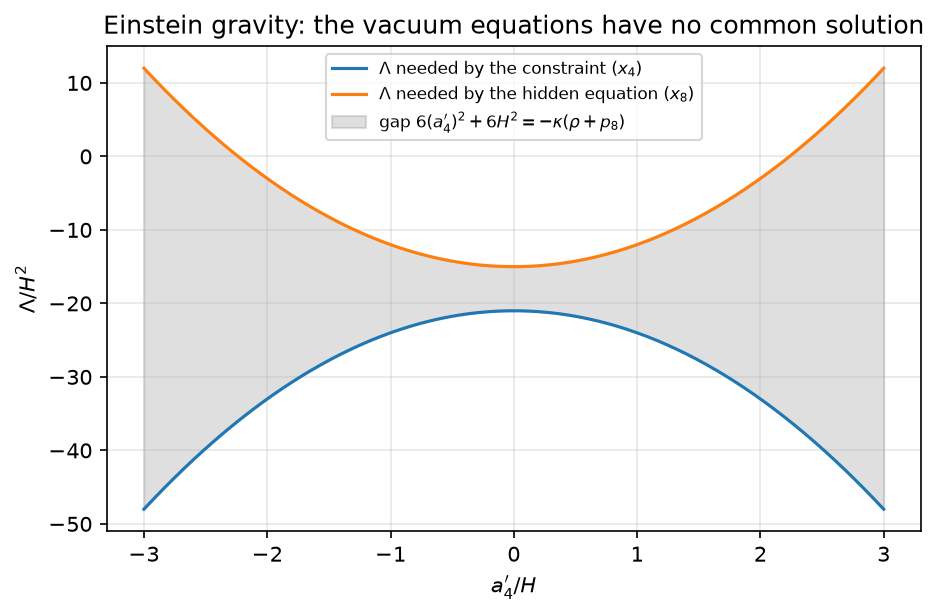

Figure 12a.5 saved as Revision/textbook/figures/12a_5_no_vacuum_gap.png


In [27]:
u = np.linspace(-3.0, 3.0, 301)  # a4'/H
lam_constraint = -(3 * u ** 2 + 21)  # Lambda/H^2 that the x4 equation needs
lam_hidden = 3 * u ** 2 - 15  # Lambda/H^2 that the x8 equation needs
fig, ax = plt.subplots()
ax.plot(u, lam_constraint, label="$\\Lambda$ needed by the constraint ($x_4$)")
ax.plot(u, lam_hidden, label="$\\Lambda$ needed by the hidden equation ($x_8$)")
ax.fill_between(u, lam_constraint, lam_hidden, color="grey", alpha=0.25,
                label="gap $6(a_4')^2+6H^2=-\\kappa(\\rho+p_8)$")
ax.set_xlabel("$a_4'/H$")
ax.set_ylabel("$\\Lambda/H^2$")
ax.set_title("Einstein gravity: the vacuum equations have no common solution")
ax.legend(fontsize=8, loc="upper center")  # the empty area above the curves
save_figure(fig, "no_vacuum_gap",
            "Einstein gravity without a source: the value of $\\Lambda/H^2$ that the "
            "time equation (constraint) requires, $-(3(a_4')^2 + 21H^2)$, and the "
            "value that the hidden $x_8$ equation requires, $3(a_4')^2 - 15H^2$, as "
            "functions of $a_4'/H$. The two curves never meet, so there is no vacuum "
            "solution for $H > 0$ and any $\\Lambda$; the grey gap between them, "
            "$6(a_4')^2 + 6H^2$, equals $-\\kappa(\\rho + p_8)$, so every source of the "
            "metric violates the null energy condition along $x_8$.")

## 14. The linear member $a_4 = A H x_4 + a_0$

For $a_4 = AHx_4 + a_0$ we have $a_4' = AH$ and $a_4'' = 0$: 3-space grows like
$e^{AHx_4}$ and the extra times shrink like $e^{-AHx_4}$ (exponential deflation
for $A > 0$). The next cell checks that then $p_3 = p_t = p_8 =: p$ (the three
pressures are equal) and that $\rho$ and $p$ are constants; it prints $\kappa\rho$
and $\kappa p$ and checks that they contain $A$ only through $A^2$: the equations
do not distinguish deflating extra times ($A > 0$) from inflating ones
($A < 0$). Deflation is a choice of sign, an initial condition, not a consequence
of the equations.

In [28]:
reproduces(sp.expand((e11 - e88).subs(LINEAR)) == 0
           and sp.expand((e55 - e88).subs(LINEAR)) == 0,
           "linear member: p3 = pt = p8 = p (any alpha_k)",
           PY, "linear_member_equal_pressures")
rho_linear = sp.expand(-(e44 + Lam).subs(LINEAR) / kappa)  # from the constraint
p_linear = sp.expand((e88 + Lam).subs(LINEAR) / kappa)  # from the hidden equation
say(f"kappa rho = {sp.expand(kappa * rho_linear)}")
say(f"kappa p = {sp.expand(kappa * p_linear)}")
check(not rho_linear.has(x4) and not p_linear.has(x4),
      "linear member: rho and p are constants")
check(sp.expand(rho_linear.subs(A, -A) - rho_linear) == 0
      and sp.expand(p_linear.subs(A, -A) - p_linear) == 0,
      "rho and p are even in A: A -> -A is a symmetry (deflation is a choice)")

PASS linear member: p3 = pt = p8 = p (any alpha_k)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    linear_member_equal_pressures
kappa rho = -360*A**6*H**6*alpha3 - 648*A**4*H**6*alpha3 + 36*A**4*H**4*alpha2 -
    1080*A**2*H**6*alpha3 + 120*A**2*H**4*alpha2 - 3*A**2*H**2*alpha1 - 2520*H**6*alpha3
    + 420*H**4*alpha2 - 21*H**2*alpha1 - Lam
kappa p = -72*A**6*H**6*alpha3 - 648*A**4*H**6*alpha3 + 12*A**4*H**4*alpha2 -
    1944*A**2*H**6*alpha3 + 168*A**2*H**4*alpha2 - 3*A**2*H**2*alpha1 + 360*H**6*alpha3 -
    180*H**4*alpha2 + 15*H**2*alpha1 + Lam
PASS linear member: rho and p are constants
PASS rho and p are even in A: A -> -A is a symmetry (deflation is a choice)


**The vacuum of the linear member.** A vacuum needs $\rho = p = 0$, so in
particular $e_{44} = e_{88}$. The next cell factors
$e_{44} - e_{88} = 6(A^2 + 1)H^2\,V$ with the polynomial

$$V = \alpha_1 - 8\alpha_2H^2(A^2 + 5) + \alpha_3 H^4(72A^4 + 144A^2 + 360).$$

In Einstein gravity $V = 1$: no vacuum. In Einstein-Gauss-Bonnet gravity
($\alpha_1 = 1$, $\alpha_3 = 0$) $V = 0$ gives
$A^2 = (1 - 40\alpha_2H^2)/(8\alpha_2H^2)$, a real $A$ only for
$0 < \alpha_2H^2 \le 1/40$. Because $e_{44}$ and $e_{88}$ contain no $a_4''$, the
same factorisation holds for EVERY $a_4$ with $AH$ replaced by $a_4'$:
$\kappa(\rho + p_8) = -6((a_4')^2 + H^2)\,V$. The cell also compares $\rho$, $p$
and $V$ with the record.

In [29]:
V = sp.expand(sp.cancel((e44 - e88).subs(LINEAR) / (6 * (A ** 2 + 1) * H ** 2)))
report("vacuum factor V", V)
reproduces(V.is_polynomial(A) and sp.expand(6 * (A ** 2 + 1) * H ** 2 * V
                                             - (e44 - e88).subs(LINEAR)) == 0,
           "e44 - e88 = 6 (A^2 + 1) H^2 V with a polynomial V",
           PY, "linear_member_vacuum_factor")
V_gauss_bonnet = sp.expand(V.subs({alpha1: 1, alpha3: 0}))
reproduces(sp.expand(V_gauss_bonnet - (1 - 8 * alpha2 * H ** 2 * (A ** 2 + 5))) == 0,
           "Gauss-Bonnet: V = 1 - 8 alpha2 H^2 (A^2 + 5)",
           PY, "einstein_gauss_bonnet_vacuum_linear")
V_any = V.subs(A, ad1 / H)  # the same polynomial with A H -> a4'
check(sp.expand((e88 - e44) + 6 * (ad1 ** 2 + H ** 2) * V_any) == 0,
      "for every a4: kappa (rho + p8) = -6 (a4'^2 + H^2) V(a4')")
linear_record = equations_json["linearMember"]
same = (sp.expand(parse(linear_record["rho"]["input"], NAMES_RECORD) - rho_linear)
        == 0
        and sp.expand(parse(linear_record["p"]["input"], NAMES_RECORD) - p_linear)
        == 0
        and sp.expand(parse(linear_record["vacuumFactor"]["input"], NAMES_RECORD)
                      - V) == 0)
reproduces(same, "rho, p and V of the linear member equal the record",
           PY, "json_linear_member")

RESULT vacuum factor V = 72*A**4*H**4*alpha3 + 144*A**2*H**4*alpha3 - 8*A**2*H**2*alpha2
    + 360*H**4*alpha3 - 40*H**2*alpha2 + alpha1
PASS e44 - e88 = 6 (A^2 + 1) H^2 V with a polynomial V
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    linear_member_vacuum_factor
PASS Gauss-Bonnet: V = 1 - 8 alpha2 H^2 (A^2 + 5)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_gauss_bonnet_vacuum_linear
PASS for every a4: kappa (rho + p8) = -6 (a4'^2 + H^2) V(a4')
PASS rho, p and V of the linear member equal the record
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    json_linear_member


## 15. The last check

The last cell checks that the five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [30]:
figure_names = ["12a_1_riemann_matrix.png", "12a_2_einstein_components.png",
                "12a_3_lovelock_heat_maps.png", "12a_4_evolution_factor.png",
                "12a_5_no_vacuum_gap.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all five figure files exist")
all_checks_passed()

PASS all five figure files exist
ALL 59 CHECKS PASSED (notebook 12a)


## 16. What this notebook showed

- From the metric alone, sympy finds 37 nonzero Christoffel symbols and 156 nonzero
  curvature components $R^{ab}{}_{mn}$ (39 with $a < b$, $m < n$), none of which
  contains the warp factor or $e^{a_4}$ (PROVED, as in the Revision record).
- The Einstein tensor is diagonal with four distinct components, and the three
  Lovelock tensors built with the generalized Kronecker delta agree, in all 64
  components, with the Rust program and the Wolfram record; $E_{(2)}$ equals the
  classical Gauss-Bonnet tensor; each $E_{(k)}$ has zero divergence (PROVED).
- The field equations reduce to a constraint ($x_4$), an evolution equation
  $a_4''F(a_4') = \kappa(p_3 - p_t)$, a hidden equation ($x_8$), and conditions on
  the source: $p_3 + p_t = 2p_8$, no dependence on $x_8$, no mixed components
  (PROVED).
- The derivative of the constraint is $3a_4'$ times the evolution equation, and
  the source must obey $\rho' = -3a_4'(p_3 - p_t)$ (PROVED).
- In Einstein gravity there is no vacuum for $H > 0$, and every source has
  $\kappa(\rho + p_8) = -6((a_4')^2 + H^2) < 0$ (PROVED).
- For the linear member $a_4 = AHx_4 + a_0$ the three pressures are equal and
  constant, and the equations contain $A$ only as $A^2$: the exponential deflation
  of the extra times ($A > 0$) is a choice of sign, not selected by the equations
  (PROVED).